# Sales Forecasting — Baseline
**Goal:** Predict daily `Revenue` and `COGS` for 2023-01-01 → 2024-07-01 using historical data (2012–2022).

**Approach:** Use deterministic feature of sales and promotions as input of XGBoost models; then ensemble them to predict final results.

# 1 - Import libraries

In [1]:
from math import sqrt
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Machine Learning
import optuna
import optuna.visualization as vis
import gc
import xgboost as xgb
from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import pickle

# 2 - Configuration

In [2]:
DATA_DIR   = '/kaggle/input/competitions/datathon-2026-round-1/'
OUT_DIR    = '/kaggle/working/'
TRAIN_FILE = DATA_DIR + 'sales.csv'
TEST_FILE  = DATA_DIR + 'sample_submission.csv' 
OUT_FILE   = OUT_DIR  + 'submission.csv'

# 3 - Data Loading

In [3]:
sales      = pd.read_csv(TRAIN_FILE, parse_dates=['Date'])
test       = pd.read_csv(TEST_FILE, parse_dates=['Date'])
products   = pd.read_csv(DATA_DIR + "products.csv")
promotions = pd.read_csv(DATA_DIR + "promotions.csv", parse_dates=["start_date", "end_date"])

print("=== DATA TIME RANGE ===")
print("Train:", sales['Date'].min(), "→", sales['Date'].max(), "rows:", len(sales))
print("Test :", test['Date'].min(),  "→", test['Date'].max(),  "rows:", len(test))

=== DATA TIME RANGE ===
Train: 2012-07-04 00:00:00 → 2022-12-31 00:00:00 rows: 3833
Test : 2023-01-01 00:00:00 → 2024-07-01 00:00:00 rows: 548


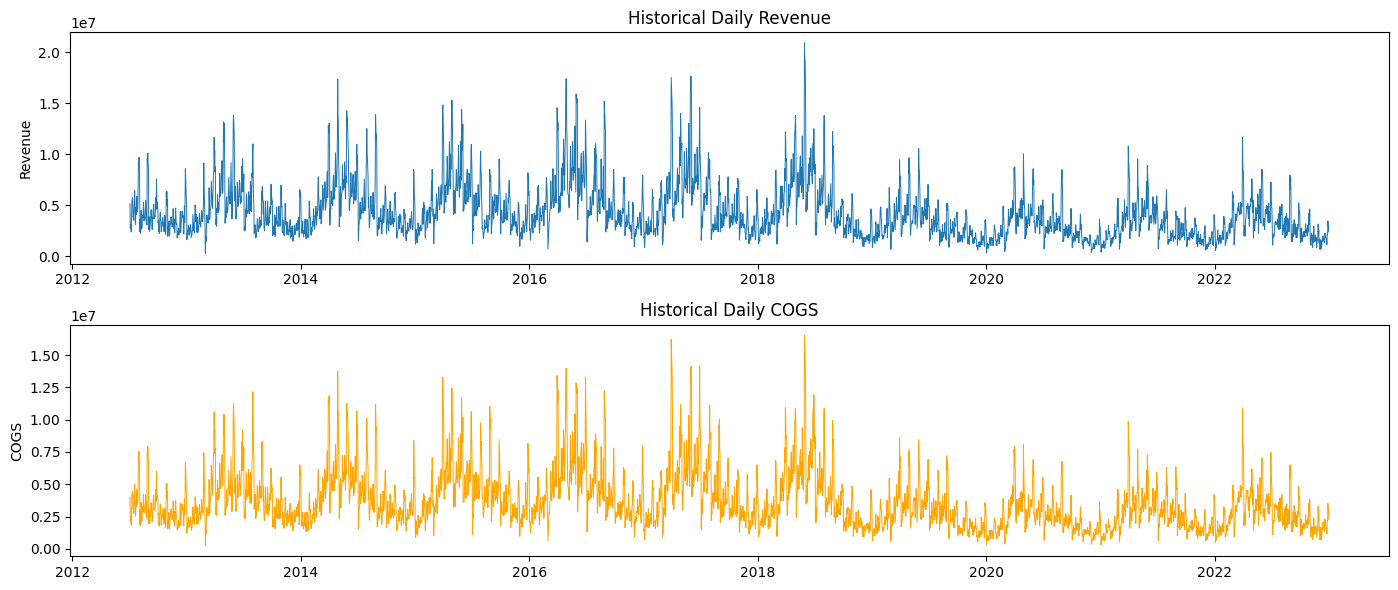

In [4]:
train = sales.copy()

fig, axes = plt.subplots(2, 1, figsize=(14, 6))
axes[0].plot(train['Date'], train['Revenue'], lw=0.7)
axes[0].set_title('Historical Daily Revenue'); axes[0].set_ylabel('Revenue')
axes[1].plot(train['Date'], train['COGS'], lw=0.7, color='orange')
axes[1].set_title('Historical Daily COGS'); axes[1].set_ylabel('COGS')
plt.tight_layout()
plt.show()

## 3.1. Seasonality
- **Week:** the data shows no weekly pattern, with very little variation between days of the week.
- **Month:** the data shows no weekly pattern, but have payday window (not too obvious).
- **Year:** the data shows yearly pattern.


# 4 - Define features
- (not exogenous; or at least, up to now.)

In [5]:
train_df = sales.copy()
train_df["is_test"] = 0
test_df = test[["Date"]].copy()
test_df["is_test"] = 1

df_featured = pd.concat([train_df, test_df], ignore_index=True)
df_featured.head()

,Date,Revenue,COGS,is_test
0,2012-07-04,5123547.94,3982991.19,0
1,2012-07-05,2751773.45,2150580.23,0
2,2012-07-06,3054029.42,2517632.84,0
3,2012-07-07,2667930.94,2108246.62,0
4,2012-07-08,2360851.90,1808622.79,0


## 4.1 - Calender-based features

In [6]:
calender_cols = [
    "day_of_week",
    "day_of_month",
    "day_of_year",
    "month",
    "quarter",
    "year"
]

df_featured["day_of_week"]  = df_featured["Date"].dt.dayofweek             #    0..6
df_featured["day_of_month"] = df_featured["Date"].dt.day                   #    1..31
df_featured["day_of_year"]  = df_featured["Date"].dt.dayofyear             #    1..366
df_featured["week"]         = df_featured["Date"].dt.isocalendar().week    #    1..53
df_featured["month"]        = df_featured["Date"].dt.month                 #    1..12
df_featured["quarter"]      = df_featured["Date"].dt.quarter               #    1..4
df_featured["year"]         = df_featured["Date"].dt.year                  # 2012..2022

df_featured.head()

,Date,Revenue,COGS,is_test,day_of_week,day_of_month,day_of_year,week,month,quarter,year
0,2012-07-04,5123547.94,3982991.19,0,2,4,186,27,7,3,2012
1,2012-07-05,2751773.45,2150580.23,0,3,5,187,27,7,3,2012
2,2012-07-06,3054029.42,2517632.84,0,4,6,188,27,7,3,2012
3,2012-07-07,2667930.94,2108246.62,0,5,7,189,27,7,3,2012
4,2012-07-08,2360851.90,1808622.79,0,6,8,190,27,7,3,2012


In [7]:
# jann_data = df_featured[df_featured["month"] == 1]

# plt.figure(figsize=(12,6))
# for year in range(2012, 2023):
#     data_year = jann_data[jann_data["year"] == year]
#     plt.plot(data_year["day_of_month"], data_year['Revenue'], label=str(year))

# plt.title("Revenue trong tháng 1 qua các năm")
# plt.xlabel("Ngày trong tháng 1")
# plt.ylabel("Revenue")
# plt.legend(title="Năm", ncol=11, loc="upper center", bbox_to_anchor=(0.5, -0.1))
# plt.grid(True)
# plt.savefig("revenue_jannuary.png", dpi=300, bbox_inches="tight")
# plt.show()

In [8]:
# avg_revenue = df_featured.groupby("day_of_week")["Revenue"].mean()
# day_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
# avg_revenue.index = [day_names[d] for d in avg_revenue.index]

# plt.figure(figsize=(10,6))
# avg_revenue.plot(kind="bar", color="skyblue", edgecolor="black")
# plt.title("Doanh thu trung bình theo ngày trong tuần")
# plt.xlabel("Ngày trong tuần")
# plt.ylabel("Doanh thu trung bình")
# plt.xticks(rotation=0)
# plt.grid(axis="y")
# plt.savefig("revenue_day_of_week.png", dpi=300, bbox_inches="tight")
# plt.show()

In [9]:
# weekly_pattern = df_featured.groupby(["week","day_of_week"])["Revenue"].mean().unstack()
# day_names = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]

# plt.figure(figsize=(12,6))
# for week in weekly_pattern.index:
#     plt.plot(day_names, weekly_pattern.loc[week], marker="o", label=f"Week {week}")

# plt.title("So sánh doanh thu theo ngày trong tuần giữa các tuần")
# plt.xlabel("Ngày trong tuần")
# plt.ylabel("Doanh thu trung bình")
# plt.legend(ncol=3, loc="upper center", bbox_to_anchor=(0.5,-0.1))
# plt.grid(True)
# plt.savefig("revenue_weeks.png", dpi=300, bbox_inches="tight")
# plt.show()

## 4.2 - Event-based features

In [10]:
df_featured["is_weekend"] = np.where(df_featured["day_of_week"].isin([5, 6]), 1, 0)
df_featured["is_payday_window"] = np.where((df_featured["day_of_month"] >= 25) | (df_featured["day_of_month"] <= 5), 1, 0)
df_featured["is_double_day"] = np.where(df_featured["month"] == df_featured["day_of_month"], 1, 0)
df_featured["days_since_start"] = (df_featured["Date"] - df_featured["Date"].min()).dt.days

df_featured.head()

,Date,Revenue,COGS,is_test,day_of_week,day_of_month,day_of_year,week,month,quarter,year,is_weekend,is_payday_window,is_double_day,days_since_start
0,2012-07-04,5123547.94,3982991.19,0,2,4,186,27,7,3,2012,0,1,0,0
1,2012-07-05,2751773.45,2150580.23,0,3,5,187,27,7,3,2012,0,1,0,1
2,2012-07-06,3054029.42,2517632.84,0,4,6,188,27,7,3,2012,0,0,0,2
3,2012-07-07,2667930.94,2108246.62,0,5,7,189,27,7,3,2012,1,0,1,3
4,2012-07-08,2360851.90,1808622.79,0,6,8,190,27,7,3,2012,1,0,0,4


## 4.3 - Holiday-based features

In [11]:
TET_LUNAR_NEW_YEAR = {
    2012: "2012-01-23",
    2013: "2013-02-10",
    2014: "2014-01-31",
    2015: "2015-02-19",
    2016: "2016-02-08",
    2017: "2017-01-28",
    2018: "2018-02-16",
    2019: "2019-02-05",
    2020: "2020-01-25",
    2021: "2021-02-12",
    2022: "2022-02-01",
    2023: "2023-01-22",
    2024: "2024-02-10",
    2025: "2025-01-29",
}

tet_df = pd.DataFrame(list(TET_LUNAR_NEW_YEAR.items()), columns=["year", "tet_date"])
tet_df["tet_date"] = pd.to_datetime(tet_df["tet_date"])

df_featured = df_featured.merge(tet_df, on="year", how="left")
df_featured["days_to_tet"] = (df_featured["tet_date"] - df_featured["Date"]).dt.days
df_featured["is_pre_tet_rush"] = np.where((df_featured["days_to_tet"] > 0) & (df_featured["days_to_tet"] <= 21), 1, 0)
df_featured["is_tet_holiday"] = np.where((df_featured["days_to_tet"] <= 0) & (df_featured["days_to_tet"] >= -6), 1, 0)
df_featured.drop(columns=["tet_date"], inplace=True)

df_featured.head()

,Date,Revenue,COGS,is_test,day_of_week,day_of_month,day_of_year,week,month,quarter,year,is_weekend,is_payday_window,is_double_day,days_since_start,days_to_tet,is_pre_tet_rush,is_tet_holiday
0,2012-07-04,5123547.94,3982991.19,0,2,4,186,27,7,3,2012,0,1,0,0,-163,0,0
1,2012-07-05,2751773.45,2150580.23,0,3,5,187,27,7,3,2012,0,1,0,1,-164,0,0
2,2012-07-06,3054029.42,2517632.84,0,4,6,188,27,7,3,2012,0,0,0,2,-165,0,0
3,2012-07-07,2667930.94,2108246.62,0,5,7,189,27,7,3,2012,1,0,1,3,-166,0,0
4,2012-07-08,2360851.90,1808622.79,0,6,8,190,27,7,3,2012,1,0,0,4,-167,0,0


## 4.4 - Promotion-based features

In [12]:
date_range = pd.date_range(start=df_featured["Date"].min(), end=df_featured["Date"].max())
daily_promos = pd.DataFrame({"Date": date_range})
daily_promos["is_promo_active"] = 0
daily_promos["max_discount"] = 0.0

for _, row in promotions.iterrows():
    mask = (daily_promos["Date"] >= row["start_date"]) & (daily_promos["Date"] <= row["end_date"])
    daily_promos.loc[mask, "is_promo_active"] = 1
    if row["promo_type"] == "percentage":
        daily_promos.loc[mask, "max_discount"] = np.maximum(
            daily_promos.loc[mask, "max_discount"], row["discount_value"]
        )

df_featured = df_featured.merge(daily_promos, on="Date", how="left")
df_featured["is_promo_active"] = df_featured["is_promo_active"].fillna(0)
df_featured["max_discount"] = df_featured["max_discount"].fillna(0)

df_featured.head()

,Date,Revenue,COGS,is_test,day_of_week,day_of_month,day_of_year,week,month,quarter,year,is_weekend,is_payday_window,is_double_day,days_since_start,days_to_tet,is_pre_tet_rush,is_tet_holiday,is_promo_active,max_discount
0,2012-07-04,5123547.94,3982991.19,0,2,4,186,27,7,3,2012,0,1,0,0,-163,0,0,0,0.0
1,2012-07-05,2751773.45,2150580.23,0,3,5,187,27,7,3,2012,0,1,0,1,-164,0,0,0,0.0
2,2012-07-06,3054029.42,2517632.84,0,4,6,188,27,7,3,2012,0,0,0,2,-165,0,0,0,0.0
3,2012-07-07,2667930.94,2108246.62,0,5,7,189,27,7,3,2012,1,0,1,3,-166,0,0,0,0.0
4,2012-07-08,2360851.90,1808622.79,0,6,8,190,27,7,3,2012,1,0,0,4,-167,0,0,0,0.0


## 4.5 - Fourier Terms

In [13]:
K = 2
for k in range(1, K+1):
    df_featured[f"sin_{k}"] = np.sin(2 * np.pi * k * df_featured["day_of_year"]/365.25)
    df_featured[f"cos_{k}"] = np.cos(2 * np.pi * k * df_featured["day_of_year"]/365.25)

df_featured.head()


,Date,Revenue,COGS,is_test,day_of_week,day_of_month,day_of_year,week,month,quarter,...,days_since_start,days_to_tet,is_pre_tet_rush,is_tet_holiday,is_promo_active,max_discount,sin_1,cos_1,sin_2,cos_2
0,2012-07-04,5123547.94,3982991.19,0,2,4,186,27,7,3,...,0,-163,0,0,0,0.0,-0.058026,-0.998315,0.115856,0.993266
1,2012-07-05,2751773.45,2150580.23,0,3,5,187,27,7,3,...,1,-164,0,0,0,0.0,-0.075190,-0.997169,0.149953,0.988693
2,2012-07-06,3054029.42,2517632.84,0,4,6,188,27,7,3,...,2,-165,0,0,0,0.0,-0.092331,-0.995728,0.183874,0.982950
3,2012-07-07,2667930.94,2108246.62,0,5,7,189,27,7,3,...,3,-166,0,0,0,0.0,-0.109446,-0.993993,0.217577,0.976043
4,2012-07-08,2360851.90,1808622.79,0,6,8,190,27,7,3,...,4,-167,0,0,0,0.0,-0.126528,-0.991963,0.251022,0.967981


## 4.6 - Autoregressive Lags

In [14]:
# Sort strictly by date before shifting
df_featured = df_featured.sort_values("Date").reset_index(drop=True)

# 52-Week Lag (Preserves Day of Week YoY)
df_featured["Revenue_Lag_7"]   = df_featured["Revenue"].shift(7)
df_featured["Revenue_Lag_30"]  = df_featured["Revenue"].shift(30)
df_featured["Revenue_Lag_364"] = df_featured["Revenue"].shift(364)
df_featured["COGS_Lag_7"]   = df_featured["COGS"].shift(7)
df_featured["COGS_Lag_30"]  = df_featured["COGS"].shift(30)
df_featured["COGS_Lag_364"] = df_featured["COGS"].shift(364)

# Create training set, dropping the first year (NaN lags)
train_df = df_featured[(df_featured["is_test"] == 0) & (df_featured["Revenue_Lag_364"].notna())].copy()

# Transform absolute currency targets into YoY Growth Ratios
train_df["Rev_Ratio"] = train_df["Revenue"] / train_df["Revenue_Lag_364"]
train_df["COGS_Ratio"] = train_df["COGS"] / train_df["COGS_Lag_364"]

train_df.head()

,Date,Revenue,COGS,is_test,day_of_week,day_of_month,day_of_year,week,month,quarter,...,sin_2,cos_2,Revenue_Lag_7,Revenue_Lag_30,Revenue_Lag_364,COGS_Lag_7,COGS_Lag_30,COGS_Lag_364,Rev_Ratio,COGS_Ratio
364,2013-07-03,8038680.63,7869401.17,0,2,3,184,27,7,3,...,0.047289,0.998881,8817278.13,9411997.25,5123547.94,8290194.65,7525850.20,3982991.19,1.568968,1.975752
365,2013-07-04,2521315.44,2408274.98,0,3,4,185,27,7,3,...,0.081621,0.996663,7748199.74,5397308.75,2751773.45,7462815.86,4297393.33,2150580.23,0.916251,1.119826
366,2013-07-05,2494107.65,2432073.97,0,4,5,186,27,7,3,...,0.115856,0.993266,6285354.21,6860958.96,3054029.42,6043485.10,5505167.85,2517632.84,0.816661,0.966016
367,2013-07-06,2452372.43,2331799.51,0,5,6,187,27,7,3,...,0.149953,0.988693,9546012.78,5692902.11,2667930.94,9167617.84,4632206.37,2108246.62,0.919204,1.106037
368,2013-07-07,2958215.01,2950992.63,0,6,7,188,27,7,3,...,0.183874,0.982950,7372318.59,3843507.28,2360851.90,7149429.97,2986865.05,1808622.79,1.253029,1.631624


## 4.6 - Ultimate features

In [15]:
ultimate_features = [
    "day_of_week",
    "day_of_month",
    "day_of_year",
    "month",
    "quarter",
    "is_weekend",
    "is_payday_window",
    "is_double_day",
    "days_since_start",
    "days_to_tet",
    "is_pre_tet_rush",
    "is_tet_holiday",
    "Revenue_Lag_7",
    "Revenue_Lag_30",
    "Revenue_Lag_364",
    "sin_1",
    "cos_1",
    "sin_2",
    "cos_2",
    # "sin_3",
    # "cos_3",
    "is_promo_active",
    "max_discount",
]

# 5 - Optimize hyperparameters for XGBoost models

In [16]:
# # Validate by Cross-Validation (num_folds = 5)
# def objective(trial):
#     params = {
#         "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2),
#         "max_depth": trial.suggest_int("max_depth", 3, 10),
#         "subsample": trial.suggest_float("subsample", 0.5, 1.0),
#         "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
#         "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
#         "tree_method": "hist",
#         "random_state": 42,
#     }

#     dtrain = xgb.DMatrix(train_df[ultimate_features], label=train_df["Rev_Ratio"])

#     cv_results = xgb.cv(
#         params,
#         dtrain,
#         num_boost_round=trial.suggest_int("n_estimators", 500, 4000),
#         nfold=5,
#         metrics="rmse",
#         early_stopping_rounds=40,
#         seed=42,
#         verbose_eval=False
#     )

#     mean_rmse = cv_results["test-rmse-mean"].min()

#     trial.report(mean_rmse, step=len(cv_results))
#     if trial.should_prune():
#         raise optuna.TrialPruned()

#     return mean_rmse


# study = optuna.create_study(
#     direction="minimize",
#     pruner=optuna.pruners.MedianPruner()
# )
# study.optimize(objective, n_trials=50)

# print("Best params:", study.best_params)
# print("Best RMSE:", study.best_value)

[I 2026-04-26 04:56:22,480] A new study created in memory with name: no-name-01d229fb-4d27-4454-a767-0a03bda27896
[I 2026-04-26 04:56:25,938] Trial 0 finished with value: 0.36643071233719204 and parameters: {'learning_rate': 0.0706785671946551, 'max_depth': 4, 'subsample': 0.9802547996061028, 'colsample_bytree': 0.6581714527773921, 'min_child_weight': 5, 'n_estimators': 3988}. Best is trial 0 with value: 0.36643071233719204.
[I 2026-04-26 04:56:27,612] Trial 1 finished with value: 0.37877542596362324 and parameters: {'learning_rate': 0.18447860238277383, 'max_depth': 9, 'subsample': 0.6453646514094591, 'colsample_bytree': 0.8782832325008765, 'min_child_weight': 5, 'n_estimators': 3153}. Best is trial 0 with value: 0.36643071233719204.
[I 2026-04-26 04:56:29,561] Trial 2 finished with value: 0.3685712812882295 and parameters: {'learning_rate': 0.12073246667598546, 'max_depth': 6, 'subsample': 0.8117851459099608, 'colsample_bytree': 0.7520880537300265, 'min_child_weight': 4, 'n_estimator

Best params: {'learning_rate': 0.04947013345005278, 'max_depth': 3, 'subsample': 0.6388781991585042, 'colsample_bytree': 0.91884131499739, 'min_child_weight': 2, 'n_estimators': 1658}
Best RMSE: 0.3510084921644389


In [17]:
# xgb_params = {
#     'learning_rate': 0.04819352231316175,
#     'max_depth': 4,
#     'subsample': 0.6265191228045371,
#     'colsample_bytree': 0.9115174205138419,
#     'min_child_weight': 1,
#     'n_estimators': 2965,
#     'tree_method': "hist",
#     'random_state': 42
# }

# This params set is so stable
xgb_params = {
    "n_estimators": 3000,
    "learning_rate": 0.051170975338126104,
    "max_depth": 6,
    "subsample": 0.727881896094588,
    "colsample_bytree": 0.8429633291914377,
    "min_child_weight": 2,
    "random_state": 42,
    "tree_method": "hist",
    "device": "cuda",
}

# 5 - Ensemble Training

In [18]:
validation_years = [2020, 2021, 2022]
models_rev = []
models_cogs = []

print("Training Expanding Window Ensemble...")

for val_year in validation_years:
    print(f"\n--- Training Fold: Validation Year {val_year} ---")

    # Strict temporal split (No Leakage)
    train_mask = train_df["year"] < val_year
    val_mask = train_df["year"] == val_year

    X_train_fold = train_df[train_mask][ultimate_features]
    y_train_fold_rev = train_df[train_mask]["Rev_Ratio"]
    y_train_fold_cogs = train_df[train_mask]["COGS_Ratio"]

    X_val_fold = train_df[val_mask][ultimate_features]
    y_val_fold_rev = train_df[val_mask]["Rev_Ratio"]
    y_val_fold_cogs = train_df[val_mask]["COGS_Ratio"]

    # Initialize & Train
    model_rev = XGBRegressor(
        **xgb_params,
        early_stopping_rounds=40,
        eval_metric="rmse"
    )
    model_cogs = XGBRegressor(
        **xgb_params,
        early_stopping_rounds=40, 
        val_metric="rmse"
    )

    model_rev.fit(
        X_train_fold,
        y_train_fold_rev,
        eval_set=[(X_val_fold, y_val_fold_rev)],
        verbose=False,
    )
    model_cogs.fit(
        X_train_fold,
        y_train_fold_cogs,
        eval_set=[(X_val_fold, y_val_fold_cogs)],
        verbose=False,
    )

    print(f"Optimal Trees -> Revenue: {model_rev.best_iteration} | COGS: {model_cogs.best_iteration}")

    models_rev.append(model_rev)
    models_cogs.append(model_cogs)

Training Expanding Window Ensemble...

--- Training Fold: Validation Year 2020 ---
Optimal Trees -> Revenue: 12 | COGS: 12

--- Training Fold: Validation Year 2021 ---
Optimal Trees -> Revenue: 63 | COGS: 63

--- Training Fold: Validation Year 2022 ---
Optimal Trees -> Revenue: 275 | COGS: 209


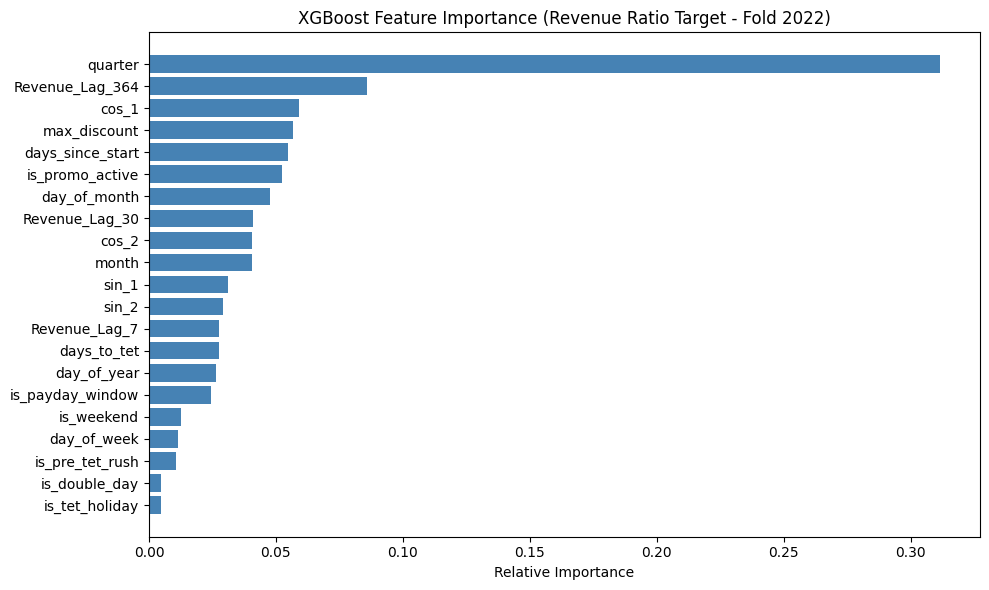

In [19]:
# Extract feature importance from the most recent fold (2022)
latest_model = models_rev[-1]
importances = latest_model.feature_importances_

imp_df = pd.DataFrame({"Feature": ultimate_features, "Importance": importances})
imp_df = imp_df.sort_values(by="Importance", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(imp_df["Feature"], imp_df["Importance"], color="steelblue")
plt.title("XGBoost Feature Importance (Revenue Ratio Target - Fold 2022)")
plt.xlabel("Relative Importance")
plt.tight_layout()
plt.show()

In [20]:
full_df = df_featured.sort_values("Date").reset_index(drop=True)
test_indices = full_df[full_df["is_test"] == 1].index

for idx in test_indices:
    # 1. Dynamically update Lag 364 from our actuals/predictions
    lag_rev = full_df.loc[idx - 364, "Revenue"]
    lag_cogs = full_df.loc[idx - 364, "COGS"]
    full_df.loc[idx, "Revenue_Lag_364"] = lag_rev
    full_df.loc[idx, "COGS_Lag_364"] = lag_cogs

    # 2. Extract features
    row_features = full_df.loc[[idx]][ultimate_features]

    # 3. Get predictions from all folds and average them
    fold_preds_rev = [model.predict(row_features)[0] for model in models_rev]
    fold_preds_cogs = [model.predict(row_features)[0] for model in models_cogs]

    pred_rev_ratio = np.mean(fold_preds_rev)
    pred_cogs_ratio = np.mean(fold_preds_cogs)

    # 4. Final Prediction = Historic Lag * Predicted Growth Ratio
    full_df.loc[idx, "Revenue"] = lag_rev * pred_rev_ratio
    full_df.loc[idx, "COGS"] = lag_cogs * pred_cogs_ratio

print("Ensemble Predictions Complete!")

Ensemble Predictions Complete!


## 7 — Export Submission

In [21]:
submission_df = full_df[full_df["is_test"] == 1][["Date", "Revenue", "COGS"]].copy()
submission_df["Date"] = submission_df["Date"].dt.strftime("%Y-%m-%d")

# Save to CSV
submission_df.to_csv("submission.csv", index=False)

print(f"Saved 'submission.csv'!")
submission_df.head()

Saved 'submission.csv'!


,Date,Revenue,COGS
3833,2023-01-01,2.722315e+06,2.967179e+06
3834,2023-01-02,1.510019e+06,1.326425e+06
3835,2023-01-03,1.165997e+06,1.039453e+06
3836,2023-01-04,1.400941e+06,1.219163e+06
3837,2023-01-05,1.242901e+06,9.989151e+05
